In [1]:

import sys
print(sys.executable)

import torch
print("GPU:", torch.cuda.is_available())

/home/rahuljana/torch_env/bin/python
GPU: True


In [2]:
import os
import sys

class SuppressPrint:
    def __enter__(self):
        self._original_stderr = sys.stderr
        sys.stderr = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stderr.close()
        sys.stderr = self._original_stderr

In [3]:
import sys
import os
import warnings
warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(".."))

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from src.config import *
from src.data_loader import get_loaders
from src.model import LandCNN
from src.train import train_model
from src.evaluate import evaluate

In [4]:
#confirm GPU
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [5]:
train_loader, val_loader, test_loader, classes = get_loaders(
    "../data/split",
    batch_size=32,
    img_size=64
)

print("Classes:", classes)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [6]:
model = LandCNN(in_channels=13, num_classes=10).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Model Ready")

Model Ready


In [34]:
train_losses = []
val_accuracies = []
train_accuracies = []  

EPOCHS = 40

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # TRAIN ACCURACY
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    train_acc = (correct / total) * 100   

    # validation
    val_acc = evaluate(model, val_loader, DEVICE)

    train_losses.append(avg_loss)
    val_accuracies.append(val_acc)
    train_accuracies.append(train_acc)   

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.2f} | Train Acc: {train_acc:.2f} | Val Acc: {val_acc:.2f}")

Epoch 1/40 | Loss: 0.11 | Train Acc: 96.64 | Val Acc: 96.20
Epoch 2/40 | Loss: 0.10 | Train Acc: 96.86 | Val Acc: 94.84
Epoch 3/40 | Loss: 0.11 | Train Acc: 96.85 | Val Acc: 94.32
Epoch 4/40 | Loss: 0.09 | Train Acc: 97.19 | Val Acc: 94.52
Epoch 5/40 | Loss: 0.09 | Train Acc: 97.14 | Val Acc: 95.43
Epoch 6/40 | Loss: 0.08 | Train Acc: 97.35 | Val Acc: 96.99
Epoch 7/40 | Loss: 0.09 | Train Acc: 97.19 | Val Acc: 93.51
Epoch 8/40 | Loss: 0.09 | Train Acc: 97.44 | Val Acc: 95.88
Epoch 9/40 | Loss: 0.09 | Train Acc: 97.24 | Val Acc: 94.22
Epoch 10/40 | Loss: 0.07 | Train Acc: 97.72 | Val Acc: 92.22
Epoch 11/40 | Loss: 0.08 | Train Acc: 97.67 | Val Acc: 96.79
Epoch 12/40 | Loss: 0.07 | Train Acc: 97.79 | Val Acc: 91.26
Epoch 13/40 | Loss: 0.07 | Train Acc: 97.93 | Val Acc: 93.46
Epoch 14/40 | Loss: 0.06 | Train Acc: 98.03 | Val Acc: 96.12
Epoch 15/40 | Loss: 0.06 | Train Acc: 98.12 | Val Acc: 96.44
Epoch 16/40 | Loss: 0.06 | Train Acc: 98.28 | Val Acc: 96.89
Epoch 17/40 | Loss: 0.07 | Train 

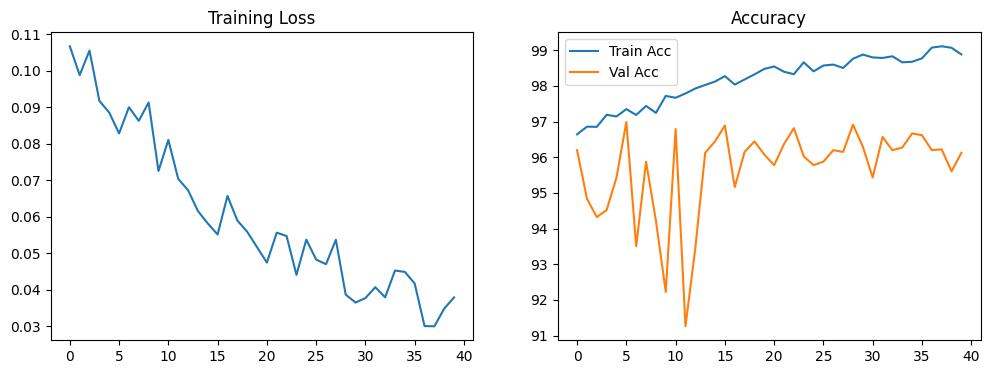

In [37]:
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(train_losses)
plt.title("Training Loss")

# Accuracy
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Acc")
plt.plot(val_accuracies, label="Val Acc")
plt.legend()
plt.title("Accuracy")

plt.show()

In [38]:
#TEST ACCURACY

test_acc = evaluate(model, test_loader, DEVICE)
print("Test Accuracy:", test_acc)

Test Accuracy: 95.23456790123457


In [39]:
#SAVE MODEL

torch.save(model.state_dict(), "../models/final_model/model.pth")
print("Model Saved")

Model Saved


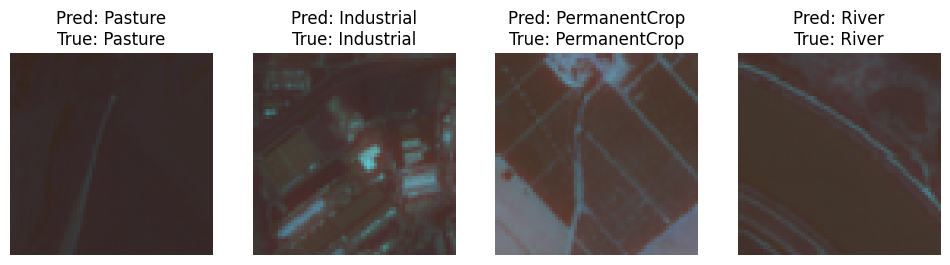

In [59]:
#SHOW RESULTS
import random
import matplotlib.pyplot as plt

model.eval()

dataset = test_loader.dataset

fig, axes = plt.subplots(1,4, figsize=(12,3))

for i in range(4):
    idx = random.randint(0, len(dataset)-1)

    img, label = dataset[idx]
    img_input = img.unsqueeze(0).to(DEVICE)

    output = model(img_input)
    _, pred = torch.max(output, 1)

    axes[i].imshow(img[:3].permute(1,2,0))
    axes[i].set_title(f"Pred: {classes[pred.item()]}\nTrue: {classes[label]}")
    axes[i].axis("off")

plt.show()

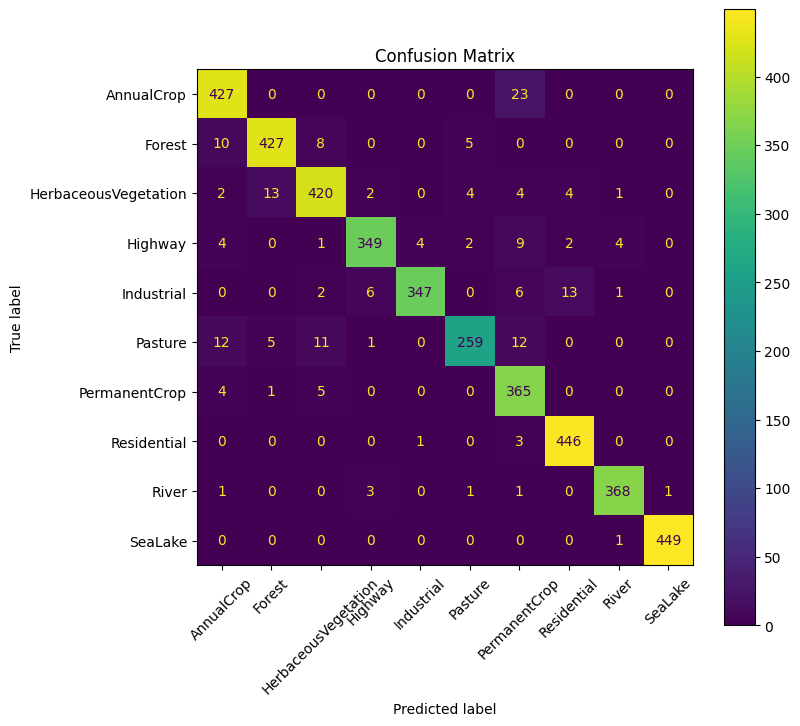

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [61]:
#ACCURACY PER CLASS
import numpy as np

class_acc = cm.diagonal() / cm.sum(axis=1)

for i, acc in enumerate(class_acc):
    print(f"{classes[i]}: {acc*100:.2f}%")

AnnualCrop: 94.89%
Forest: 94.89%
HerbaceousVegetation: 93.33%
Highway: 93.07%
Industrial: 92.53%
Pasture: 86.33%
PermanentCrop: 97.33%
Residential: 99.11%
River: 98.13%
SeaLake: 99.78%


In [24]:
# ResNet Training Cell

import sys
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import importlib
import src.resnet_model

importlib.reload(src.resnet_model)

sys.path.append(os.path.abspath(".."))
from src.resnet_model import ResNetMS

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------
# DATA LOADING 
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

val_dataset = datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# -----------------------------
# EVALUATION FUNCTION 
# -----------------------------
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return (correct / total) * 100

# -----------------------------
# MODEL
# -----------------------------
resnet_model = ResNetMS(num_classes=10).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    resnet_model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

train_losses_resnet = []
train_accuracies_resnet = []
val_accuracies_resnet = []

EPOCHS = 10

# -----------------------------
# TRAINING LOOP
# -----------------------------
best_val_acc = 0
patience = 3
counter = 0

for epoch in range(EPOCHS):
    # training code...

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break
for epoch in range(EPOCHS):
    resnet_model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = resnet_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    train_acc = (correct / total) * 100

    val_acc = evaluate(resnet_model, val_loader, DEVICE)

    train_losses_resnet.append(avg_loss)
    train_accuracies_resnet.append(train_acc)
    val_accuracies_resnet.append(val_acc)

    print(f"[ResNet] Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.2f} | Train Acc: {train_acc:.2f} | Val Acc: {val_acc:.2f}")

Using device: cuda
Early stopping triggered
[ResNet] Epoch 1/10 | Loss: 1.17 | Train Acc: 60.50 | Val Acc: 75.73
[ResNet] Epoch 2/10 | Loss: 0.71 | Train Acc: 76.16 | Val Acc: 80.16
[ResNet] Epoch 3/10 | Loss: 0.54 | Train Acc: 81.81 | Val Acc: 81.30
[ResNet] Epoch 4/10 | Loss: 0.42 | Train Acc: 85.82 | Val Acc: 81.85
[ResNet] Epoch 5/10 | Loss: 0.34 | Train Acc: 88.61 | Val Acc: 81.86
[ResNet] Epoch 6/10 | Loss: 0.26 | Train Acc: 91.01 | Val Acc: 82.02
[ResNet] Epoch 7/10 | Loss: 0.21 | Train Acc: 92.72 | Val Acc: 82.91
[ResNet] Epoch 8/10 | Loss: 0.17 | Train Acc: 94.19 | Val Acc: 82.31
[ResNet] Epoch 9/10 | Loss: 0.14 | Train Acc: 95.23 | Val Acc: 83.20
[ResNet] Epoch 10/10 | Loss: 0.12 | Train Acc: 95.96 | Val Acc: 82.56


In [25]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def test_model(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    accuracy = (correct / total) * 100
    return accuracy



test_accuracy = test_model(resnet_model, val_loader, DEVICE)

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 82.56%


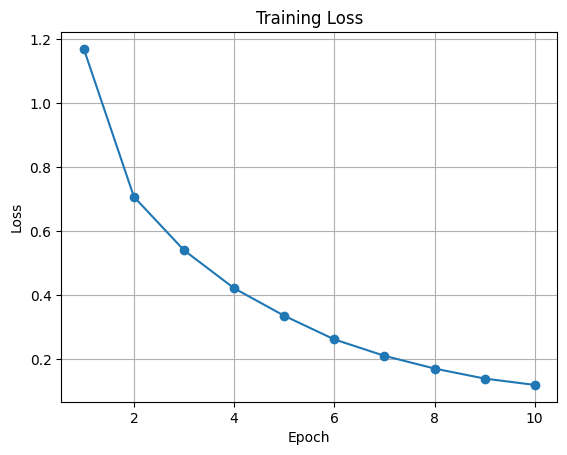

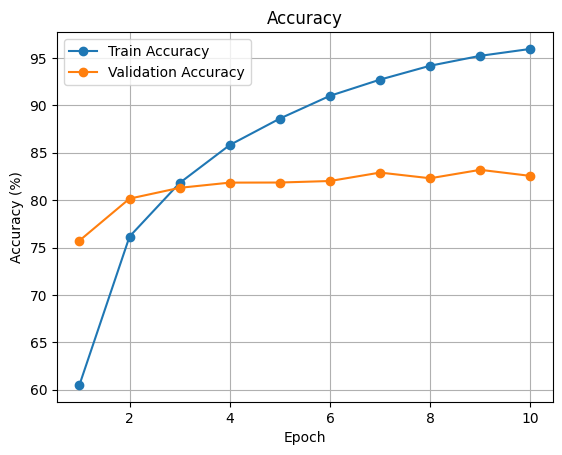

In [26]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses_resnet) + 1))

# Loss Graph
plt.figure()
plt.plot(epochs, train_losses_resnet, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

# Accuracy Graph
plt.figure()
plt.plot(epochs, train_accuracies_resnet, marker='o', label="Train Accuracy")
plt.plot(epochs, val_accuracies_resnet, marker='o', label="Validation Accuracy")

plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid()
plt.show()

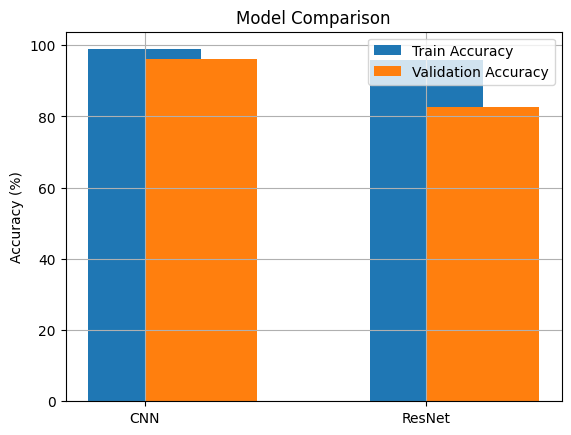

In [ ]:
import matplotlib.pyplot as plt

# Final accuracies 
cnn_train_acc = 98.88
cnn_val_acc = 96.12

resnet_train_acc = 95.96
resnet_val_acc = 82.56

models = ["CNN", "ResNet"]
train_acc = [cnn_train_acc, resnet_train_acc]
val_acc = [cnn_val_acc, resnet_val_acc]

x = range(len(models))

plt.figure()

# Train Accuracy
plt.bar(x, train_acc, width=0.4, label="Train Accuracy", align='center')

# Validation Accuracy
plt.bar(x, val_acc, width=0.4, label="Validation Accuracy", align='edge')

plt.xticks(x, models)
plt.ylabel("Accuracy (%)")
plt.title("Model Comparison")
plt.legend()
plt.grid()

plt.show()